In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho do arquivo
URL = r"C:\Users\Usuário\Downloads\SCTEC\AULAS SCTEC\turma-visualizacao-de-dados\alunos\lourenco_lemos\semana_04\base_rh.csv"

# Lê o CSV
df = pd.read_csv(URL, encoding="latin1", sep=";")

# Padroniza nomes das colunas
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print(df.columns)

# Converte salário para número
df["Salario"] = (
    df["Salario"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df["Salario"] = pd.to_numeric(df["Salario"], errors="coerce")

# Converte data
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Extrai o ano da data de admissão para poder agrupar por ano
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

# Conta quantos funcionários foram admitidos em cada ano
admissoes_ano = (
    df.groupby("Ano_Admissao")["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Admissoes"})
    .sort_values("Ano_Admissao")
)
# Filtra a data de admissão entre 2020 e 2024
admissoes_ano = admissoes_ano[
    (admissoes_ano["Ano_Admissao"] >= 2020) &
    (admissoes_ano["Ano_Admissao"] <= 2024)
]
print(admissoes_ano)


Index(['ID_Funcionario', 'Nome', 'Departamento', 'Cargo', 'Salario',
       'Data_Admissao', 'Genero', 'Idade', 'Estado_Civil', 'Status'],
      dtype='str')
   Ano_Admissao  Admissoes
5          2020         94
6          2021         94
7          2022        108
8          2023        106
9          2024        113


In [5]:
# Conta quantos funcionários existem em cada combinação Departamento + Cargo
headcount = (
    df.groupby(["Departamento", "Cargo"])["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Quantidade"})
)

print(headcount.to_string(index=False))

Departamento       Cargo  Quantidade
  Financeiro    Analista          40
  Financeiro  Assistente          30
  Financeiro Coordenador          37
  Financeiro     Gerente          44
  Financeiro     Técnico          38
   Logística    Analista          29
   Logística  Assistente          38
   Logística Coordenador          38
   Logística     Gerente          33
   Logística     Técnico          18
    Produção    Analista          22
    Produção  Assistente          41
    Produção Coordenador          40
    Produção     Gerente          43
    Produção     Técnico          36
          RH    Analista          32
          RH  Assistente          35
          RH Coordenador          44
          RH     Gerente          30
          RH     Técnico          25
          TI    Analista          31
          TI  Assistente          25
          TI Coordenador          28
          TI     Gerente          31
          TI     Técnico          32
      Vendas    Analista          24
 

In [9]:
# ============================================
# TABELA DE METAS
# ============================================

metas = pd.DataFrame({
    "Departamento": [
        "Financeiro",
        "Logística",
        "Produção",
        "RH",
        "TI",
        "Vendas"
    ],
    "Meta_Headcount": [190, 160, 200, 150, 150, 150]
})

print(metas)

  Departamento  Meta_Headcount
0   Financeiro             190
1    Logística             160
2     Produção             200
3           RH             150
4           TI             150
5       Vendas             150


In [10]:
# ============================================
# MERGE LEFT
# ============================================
total_departamento = (
    df.groupby("Departamento")["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Total_Funcionarios"})
)

comparacao = pd.merge(
    total_departamento,
    metas,
    on="Departamento",
    how="left"
)

print(comparacao)

  Departamento  Total_Funcionarios  Meta_Headcount
0   Financeiro                 189             190
1    Logística                 156             160
2     Produção                 182             200
3           RH                 166             150
4           TI                 147             150
5       Vendas                 160             150


In [12]:
# ============================================
# META ATINGIDA?
# ============================================

comparacao["Meta_Atingida"] = (
    comparacao["Total_Funcionarios"]
    >=
    comparacao["Meta_Headcount"]
)

print(comparacao)

  Departamento  Total_Funcionarios  Meta_Headcount  Meta_Atingida
0   Financeiro                 189             190          False
1    Logística                 156             160          False
2     Produção                 182             200          False
3           RH                 166             150           True
4           TI                 147             150          False
5       Vendas                 160             150           True


In [13]:
# ============================================
# TABELA PIVOT
# ============================================

pivot_salario = pd.pivot_table(
    df,
    values="Salario",
    index="Departamento",
    columns="Genero",
    aggfunc="mean"
)

print(pivot_salario)

Genero                  F            M
Departamento                          
Financeiro    8467.258571  8208.561939
Logística     8843.485258  8944.411864
Produção      8797.639529  9118.663711
RH            9009.201250  8546.056410
TI            8107.010139  8177.382267
Vendas        8926.643896  7751.590120


In [14]:
# ============================================
# DIFERENÇA F - M
# ============================================

pivot_salario["Diferenca_F_M"] = (
    pivot_salario["F"]
    -
    pivot_salario["M"]
)

print(pivot_salario)

Genero                  F            M  Diferenca_F_M
Departamento                                         
Financeiro    8467.258571  8208.561939     258.696633
Logística     8843.485258  8944.411864    -100.926607
Produção      8797.639529  9118.663711    -321.024182
RH            9009.201250  8546.056410     463.144840
TI            8107.010139  8177.382267     -70.372128
Vendas        8926.643896  7751.590120    1175.053776


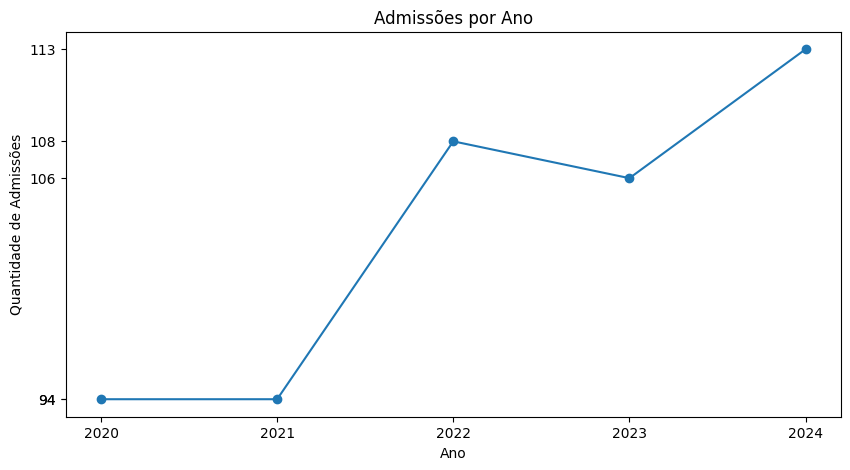

In [ ]:
import matplotlib.pyplot as plt

# ============================================
# GRÁFICO DE ADMISSÕES
# ============================================

plt.figure(figsize=(10,5))

plt.plot(
    admissoes_ano["Ano_Admissao"],
    admissoes_ano["Admissoes"],
    marker="o"
)
# Ajusta eixo X
plt.xticks(admissoes_ano["Ano_Admissao"])

# Ajusta eixo Y
plt.yticks(admissoes_ano["Admissoes"])

plt.title("Admissões por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Admissões")

plt.grid(False)

plt.show()

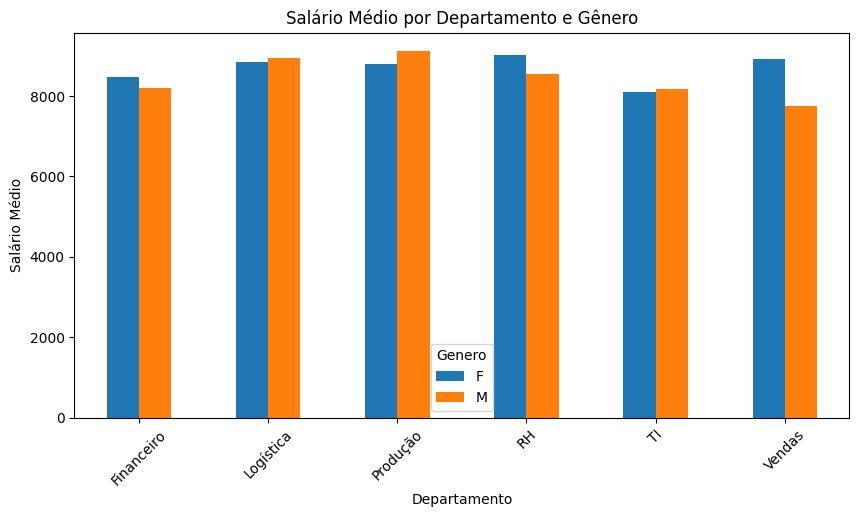

In [20]:
# ============================================
# GRÁFICO SALÁRIO MÉDIO POR GÊNERO
# ============================================

pivot_salario[["F", "M"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Salário Médio por Departamento e Gênero")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio")

plt.xticks(rotation=45)

plt.show()